# Import Required Modules

In [1]:
import plotly.express as px
from sklearn.decomposition import PCA
import scipy.io as sio
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Load Data from matfile 

In [2]:
phase2_data = sio.loadmat('../data/phase2_data_20220215.mat')
print(phase2_data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'Fs', 'mine', 'note', 'wavdir', 'x', 'y', 'SNR'])


# Prepare Pandas Dataframe

In [3]:

df_x  = pd.DataFrame(phase2_data["x"].T)
df_y  = pd.DataFrame(phase2_data["y"].T, columns=["y"])
# df_mine = pd.DataFrame(phase2_data["mine"].T, columns=["mine"])

df = pd.concat([df_x, df_y], axis=1, join="inner")

df = df.dropna()

display(df)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,...,4761,4762,4763,4764,4765,4766,4767,4768,4769,4770,4771,4772,4773,4774,4775,4776,4777,4778,4779,4780,4781,4782,4783,4784,4785,4786,4787,4788,4789,4790,4791,4792,4793,4794,4795,4796,4797,4798,4799,y
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000031,0.000061,0.000000,0.000000,-0.000031,-0.000031,0.000031,-0.000031,-0.000031,0.000000,-0.000031,0.000031,0.000000,0.000000,0.000000,0.000031,0.000000,0.000031,-0.000061,0.000000,-0.000061,0.000000,0.000031,0.000031,0.000000,0.000000,0.000000,0.000000,0.000031,0.000000,0.000031,0.000000,-0.000061,0.000000,0.0
1,-0.000061,-0.000031,-0.000092,-0.000031,-0.000061,-0.000061,-0.000061,-0.000061,-0.000031,-0.000061,-0.000031,-0.000031,0.000031,-0.000061,0.000000,0.000061,-0.000031,0.000031,0.000031,0.000000,0.000031,0.000031,0.000031,0.000061,0.000031,0.000031,0.000092,0.000000,0.000031,0.000061,0.000031,0.000031,0.000122,-0.000031,0.000031,0.000000,0.000092,0.000000,0.000031,0.000031,...,-0.000916,-0.000946,-0.000916,-0.001007,-0.001007,-0.001007,-0.001007,-0.001068,-0.000977,-0.000885,-0.000763,-0.000580,-0.000732,-0.000610,-0.000641,-0.000610,-0.000580,-0.000488,-0.000397,-0.000397,-0.000336,-0.000305,-0.000183,-0.000183,-0.000092,-0.000092,-0.000092,-0.000061,0.000000,-0.000031,-0.000031,0.000031,-0.000061,0.000000,0.000031,0.000122,0.000031,0.000092,0.000092,0.0
2,0.000000,-0.000122,0.000000,-0.000061,-0.000031,-0.000031,0.000000,-0.000031,0.000031,-0.000061,0.000031,-0.000061,0.000031,-0.000031,0.000000,-0.000031,0.000000,-0.000061,-0.000031,0.000000,-0.000061,0.000000,-0.000031,-0.000031,-0.000061,0.000031,-0.000061,-0.000031,0.000000,-0.000031,0.000000,-0.000031,0.000000,0.000000,-0.000061,0.000031,-0.000031,0.000000,0.000000,-0.000031,...,0.001373,0.001190,0.001282,0.001190,0.001160,0.001038,0.001068,0.000977,0.000946,0.000946,0.000885,0.000854,0.000793,0.000824,0.000732,0.000702,0.000732,0.000641,0.000610,0.000580,0.000458,0.000427,0.000305,0.000366,0.000427,0.000336,0.000275,0.000244,0.000183,0.000183,0.000183,0.000244,0.000031,0.000061,0.000092,0.000000,0.000031,-0.000153,-0.000122,0.0
3,0.000061,-0.000031,0.000000,0.000000,0.000000,0.000000,-0.000031,0.000000,0.000000,-0.000031,-0.000031,-0.000031,-0.000061,-0.000031,-0.000061,0.000000,-0.000061,-0.000031,-0.000031,-0.000061,-0.000031,-0.000031,0.000000,-0.000061,-0.000031,0.000000,-0.000031,-0.000031,-0.000031,-0.000031,-0.000031,-0.000061,0.000000,-0.000061,-0.000031,-0.000061,-0.000031,-0.000061,-0.000031,-0.000061,...,-0.000153,-0.000153,-0.000183,-0.000153,-0.000153,-0.000122,-0.000153,-0.000183,-0.000092,-0.000153,-0.000122,-0.000122,-0.000122,-0.000122,-0.000092,-0.000092,-0.000031,-0.000061,0.000000,0.000061,-0.000031,0.000061,0.000000,0.000122,0.000031,0.000092,0.000061,0.000092,0.000122,0.000061,0.000122,0.000153,0.000153,0.000214,0.000183,0.000244,0.000244,0.000305,0.000275,0.0
4,0.000000,0.000031,-0.000061,0.000061,0.000000,0.000000,0.000031,-0.000031,-0.000031,0.000000,0.000000,-0.000031,-0.000031,0.000031,-0.000061,0.000000,-0.000061,0.000000,0.000000,-0.000031,0.000000,0.000061,-0.000061,0.000031,-0.000031,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000031,-0.000031,0.000000,-0.000031,-0.000061,0.000061,-0.000031,-0.000031,0.000000,...,0.000122,0.000061,0.000122,0.000061,0.000092,0.000183,0.000061,0.000153,0.000183,0.000183,0.000214,0.000122,0.000214,0.000153,0.000153,0.000092,0.000122,0.000122,0.000122,0.000061,0.000183,0.000061,0.000031,0.000153,0.000122,0.000153,0.000153,0.000214,0.000122,0.000183,0.000244,0.000275,0.00021

# Seperate features from the Dataframe
## Standardize data 
Mean = 0, Variance = 1
## PCA Analysis
1. 2 Component analysis
1. 3D Scatter plot giving z=-1 for label=0 and z=1 for label=1

In [4]:
X = df.iloc[:, :-1]

scaler = StandardScaler()
scaler.fit(X)
X = scaler.transform(X)

pca = PCA(n_components=2)

components = pca.fit_transform(X)

new_axis = phase2_data["y"].T.copy()
new_axis[new_axis == 0] = -1

df_components = pd.DataFrame(components, columns=["PC1", "PC2"])
df_new_axis = pd.DataFrame( new_axis, columns=["z"])

df_kernel = pd.concat([df_components, df_new_axis], axis=1, join="inner")

one_count = np.sum(df_kernel["z"] == 1)
print("one_count", one_count)
zero_count = np.sum(df_kernel["z"] == -1)
print("zero_count", zero_count)

fig = px.scatter_3d(df_kernel, x="PC1", y="PC2", z="z", color=df['y'])
fig.show()
fig.write_image("../assets/p2_pca_3d.png")

one_count 3124
zero_count 3856


In [5]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

# Displaying how the waveform of both classes looks

0      -0.000061
1       0.000000
2       0.000000
3       0.000031
4      -0.000031
          ...   
4796   -0.000580
4797   -0.000580
4798   -0.000580
4799   -0.000305
y       0.000000
Name: 12, Length: 4801, dtype: float64

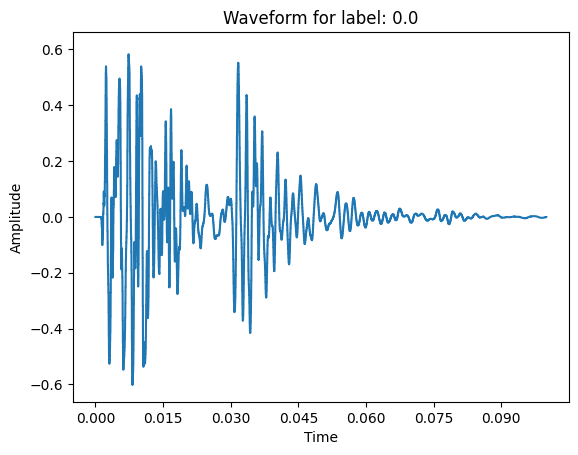

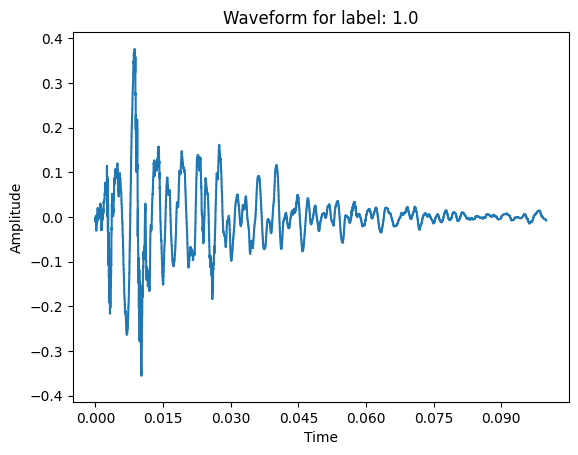

In [7]:
example = df.loc[12]
label = example.values[-1]
sample_rate_phase1 = 48000

display(example)
#Displaying 1st Waveform
example = example[:-1].values
plt.figure()
librosa.display.waveshow(example, sr=sample_rate_phase1)
plt.title('Waveform for label: {}'.format(label))
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.show()

example9922 = df.iloc[8439, :-1].values
label9922 = df.iloc[8439, -1]
#Displaying 2nd Waveform
plt.figure()
librosa.display.waveshow(example9922, sr=sample_rate_phase1)
plt.title('Waveform for label: {}'.format(label9922))
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.show()


# PCA analysis
1. Analysing how many components capture different amounts of variance in the features
1. Variance vs Number of Components Plot
1. Plot the components

cumulative_variance: [0.04752682 0.08676244 0.11996877 ... 1.         1.         1.        ]


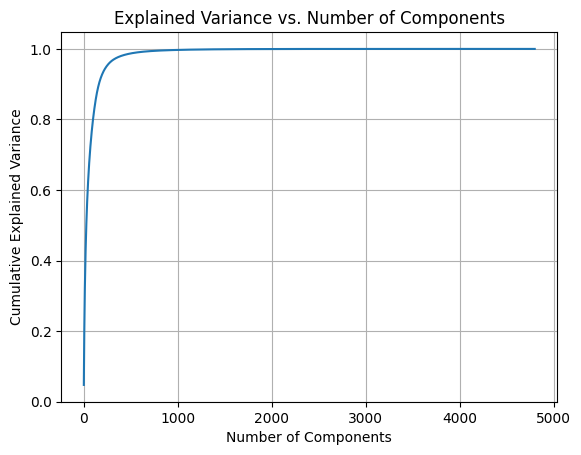

Number of components retaining 95% variance: 242
Number of components retaining 70% variance: 65
Number of components retaining 80% variance: 99


In [9]:
# Assuming X is your data
pca = PCA(n_components=None)
pca.fit(X)

# Calculate cumulative explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

print("cumulative_variance:", cumulative_variance)

# Plot cumulative explained variance
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs. Number of Components')
plt.grid(True)
plt.show()

# Choose n_components based on the plot or a threshold
n_components = np.argmax(cumulative_variance >= 0.95) + 1
print(f'Number of components retaining 95% variance: {n_components}')

n_components = np.argmax(cumulative_variance >= 0.70) + 1
print(f'Number of components retaining 70% variance: {n_components}')

n_components = np.argmax(cumulative_variance >= 0.80) + 1
print(f'Number of components retaining 80% variance: {n_components}')

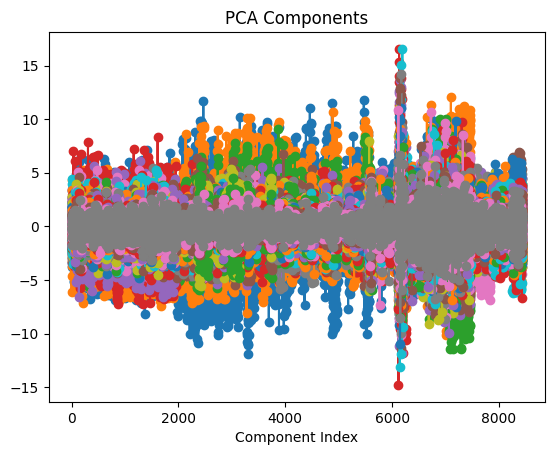

In [ ]:
# Apply PCA with the selected number of components
pca_final = PCA(n_components=99)
X_reduced = pca_final.fit_transform(X)

df_pca_plot = pd.DataFrame(X_reduced, columns=[f"PC{i+1}" for i in range(99)])
plt.figure()
plt.plot(df_pca_plot, marker='o', linestyle='-')
plt.title('PCA Components')
plt.xlabel('Component Index')
plt.show()

# Listening to audio

In [57]:
from IPython.display import Audio

print("label", label)
Audio(example, rate=sample_rate_phase1)


label 0.0


In [45]:
display(df.loc[1009])
print(phase2_data["wavdir"][1009])

0       0.000000
1       0.000000
2       0.000000
3       0.000000
4       0.000000
          ...   
4796   -0.000061
4797   -0.000061
4798   -0.000214
4799   -0.000336
y       0.000000
Name: 1009, Length: 4801, dtype: float64

[(array(['09-36-12_D.wav'], dtype='<U14'), array(['D:\\work\\usask_research\\projects\\automatic_scaling_bar\\phase2_analysis\\recordings\\K3_01_12_2021_raw'],
       dtype='<U98'), array(['04-Jun-2021 00:00:00'], dtype='<U20'), array([[128108]], dtype=int32), array([[0]], dtype=uint8), array([[738311]], dtype=int32))]


# Saving waveforms as pdf seperately for drummy and tight
Some audios are corrupted

In [ ]:
drummy_df = df[df["y"] == 0]
display(drummy_df)
from matplotlib.backends.backend_pdf import PdfPages

with PdfPages('../assets/drummy_waves.pdf') as pdf:

    for index, row in drummy_df.iterrows():
        # Create a new figure for each plot
        plt.figure()
        librosa.display.waveshow(row[:-1].values, sr=sample_rate_phase1)
        plt.title('Waveform {} for label: {}'.format(row.name, row.values[-1]))
        plt.xlabel('Time')
        plt.ylabel('Amplitude')
        # Save the current figure to the PDF
        pdf.savefig()
        # Close current figure to release memory
        plt.close()

In [55]:
tight_df = df[df["y"] == 1]
display(tight_df)
from matplotlib.backends.backend_pdf import PdfPages

with PdfPages('../assets/tight_waves.pdf') as pdf:

    for index, row in tight_df.iterrows():
        # Create a new figure for each plot
        plt.figure()
        librosa.display.waveshow(row[:-1].values, sr=sample_rate_phase1)
        plt.title('Waveform {} for label: {}'.format(row.name, row.values[-1]))
        plt.xlabel('Time')
        plt.ylabel('Amplitude')
        # Save the current figure to the PDF
        pdf.savefig()
        # Close current figure to release memory
        plt.close()

,0,1,2,3,4,5,6,7,8,9,...,4791,4792,4793,4794,4795,4796,4797,4798,4799,y
100,0.000000,0.000000,0.000000,0.000000,0.004913,0.007324,0.000244,0.000214,0.000214,0.000183,...,-0.000061,-0.000031,-0.000061,-0.000061,-0.000031,-0.000031,-0.000061,-0.000061,-0.000031,1.0
303,0.000000,0.000000,0.000000,0.000000,-0.002808,-0.004761,0.000366,0.000305,0.000305,0.000275,...,0.000000,0.000031,0.000000,0.000092,0.000000,0.000031,0.000031,0.000000,0.000000,1.0
304,0.000061,0.000122,0.000031,0.000092,0.000092,0.000061,0.000031,0.000122,0.000031,0.000031,...,0.000397,0.000366,0.000366,0.000397,0.000336,0.000366,0.000397,0.000305,0.000366,1.0
305,-0.000122,-0.000214,-0.000092,-0.000214,-0.000092,-0.000092,-0.000061,0.000061,0.000061,0.000153,...,0.000122,0.000122,0.000092,0.000031,0.000061,0.000153,0.000122,0.000092,0.000153,1.0
306,-0.000092,0.000031,-0.000061,-0.000061,0.000000,-0.000031,-0.000061,-0.000031,-0.000031,-0.000031,...,-0.000214,-0.000244,-0.000244,-0.000214,-0.000214,-0.000183,-0.000244,-0.000214,-0.000244,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9918,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.036957,0.042694,0.047516,0.050690,0.052979,0.053772,0.053741,0.054047,0.054321,1.0
9919,0.000031,0.000000,-0.000061,-0.000031,-0.000061,0.000092,0.000031,0.000122,0.000153,0.000183,...,-0.015991,-0.017029,-0.017975,-0.018951,-0.020050,-0.020691,-0.021271,-0.021759,-0.021851,1.0
9920,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.025238,-0.031494,-0.038025,-0.046021,-0.053101,-0.060120,-0.068390,-0.076202,-0.082703,1.0
9921,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.022125,-0.022217,-0.022217,-0.022186,-0.021851,-0.021332,-0.020721,-0.019806,-0.018616,1.0
